# Marketing Campaign
## Exploratory Data Analysis

Our project aims to predict customer response to targeted marketing campaigns for a retail food company. The next campaign will focus on a monthly food basket subscription service.
The main challenge lies in identifying which customers are most likely to respond positively to this offer, as untargeted marketing efforts result in low response rates and wasted resources.  
  
The goal of this exploratory data analysis is to:

- Understand the structure and quality of the dataset
- Identify potential data issues (missing values, outliers, imbalance)
- Explore customer characteristics and purchasing behavior
- Detect patterns associated with campaign response
- Extract insights that will guide feature engineering and model development

This analysis focuses on identifying predictive signals relevant to the target variable Response.

In [1]:
!git clone https://github.com/vanessassess/ML_Group_AH.git

fatal: destination path 'ML_Group_AH' already exists and is not an empty directory.


In [2]:
%cd ML_Group_AH

/content/ML_Group_AH


In [3]:
!ls data

marketing_campaign_clean.csv  marketing_campaign.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv("data/marketing_campaign.csv", sep=";")

### 1. Dataset Overview
Before proceeding with deeper analysis, it is important to understand the basic structure of the dataset, including its size, variable types, and overall composition.  

This step helps identify potential preprocessing needs and provides context for subsequent analysis.

In [5]:
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.")
df.head()

The dataset has 2240 rows and 29 columns.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


The dataset contains 2240 observations and 26 variables, including demographics,
purchase behavior and previous campaign responses.

Most variables are numerical, with a few categorical features such as `Education` and `Marital_Status`, and as we may notice `Dt_Customer` is stored as an object type. On this initial inspection it is possible to observe that some variables might contain missing values and outliers, which will be analysed in the data quality assesment stage.


### 2. Initial Target Variable Analysis
Before exploring the predictors, it is essential to analyze the target variable `Response`.

Understanding its distribution allows us to assess class imbalance and anticipate potential modeling challenges.

The target variable is naturally binary, as it indicates whether the customer accepted the latest marketing campaign offer. If Yes then `Response` = 1, if No then `Response` = 0.


Response distribution:
Response
0    1906
1     334
Name: count, dtype: int64 

Response
0    0.851
1    0.149
Name: proportion, dtype: float64


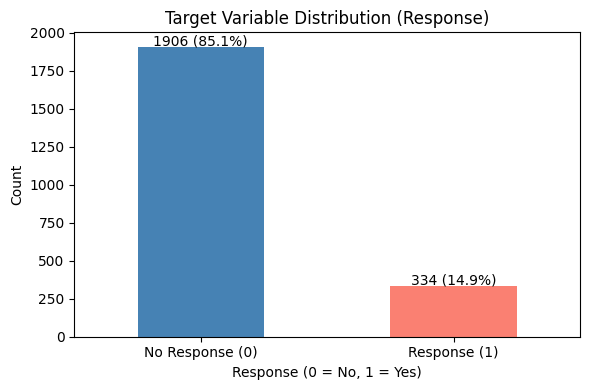

In [8]:
print("Response distribution:")
print(df['Response'].value_counts(), "\n")
print(df['Response'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
df['Response'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Variable Distribution (Response)')
ax.set_xlabel('Response (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Response (0)', 'Response (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()+10), ha='center')
plt.tight_layout()
plt.show()

Since only approximately 15% of customers responded to the campaign, we can conclude that the dataset shows a clear class imbalanced.

In cases where the classes are imbalanced, and many customers did not respond to campaign, accuracy can be misleading. The model will predict always 0, and as 85% of the customers did not answer, the model would stil acheive a high accuracy.
 Therefore,metrics like ROC-AUC and Precision will be futher use as evaluation metrics, as they better capture the model’s ability to correctly identify who are likely to respond to the campaign.  

 As a marketing prespective, well predicting which customers are likely to respond allows the company to target only interested customers, reduce marketing costs and increase  the campaign conversion rate.

### 3. Data Quality and Missing values
Assessing data quality is a critical step before model development.
In this section, we examine missing values, detect potential inconsistencies,
and evaluate whether corrective actions are required.

#### 3.1 Missing values overview

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Only the variable `Income` contains 24 missing observations, which represent a small proportion of the dataset.

Since the percentage is very low, removal is possible but imputation is preferable to preserve data, so median imputation will be applied during teh preprocessing stage.

#### 3.2 Data Types overview

In [10]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


As mentioned before, `Dt_Customer` is stored as an object type although it represents the date when the customer register or created their account with the company. Thus, it will be converted to datetime format during preprocessing.

The variables `Education` and `Maritional_Status` are stored as object types, indicating categorical customer attributes.

Several variables represent binary indicators, such as previous campaign acceptance variables and the target variable that will be used for prediction : `Response`.

#### 3.3 Duplicates

In [11]:
df.duplicated().sum()
dup_lines = df.duplicated().sum()

if dup_lines == 0:
    print("The dataset does not contain duplicated lines.")
else:
    print(f"The dataset contains {dup_lines} duplicated lines.")

The dataset does not contain duplicated lines.


In [12]:
dup_ids = df['ID'].duplicated().sum()

if dup_ids == 0:
    print("The dataset does not contain duplicated IDs.")
else:
    print(f"The dataset contains {dup_ids} duplicated IDs.")

The dataset does not contain duplicated IDs.


Data consistency was verified by checking customer identifiers across the dataset, confirming that no duplicated IDs were found.

#### 3.4 Constant variables

In [13]:
df.nunique().sort_values(ascending=True)

,0
Z_Revenue,1
Z_CostContact,1
AcceptedCmp3,2
AcceptedCmp4,2
AcceptedCmp5,2
AcceptedCmp1,2
Complain,2
AcceptedCmp2,2
Response,2
Teenhome,3


The varaibles `Z_CostContact` and `Z_Revenue`, that represent the campaign economic analysis, to calculate the expected revenue or the cost per contact, are not customer features. Both appear to be constant among all observations, leading to conclude that they do not provide predictive modelling value.  

### 4. Data Preprocessing

Following the data quality assessment, preprocessing steps were applied to improve the dataset and prepare it for futher analysis and machine learning modelling. Here missing values, data types and some data inconsistencies will be handled.

#### 4.1 Handling Income Missing values

In [14]:
df['Income'].describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [15]:
missing_pct = df['Income'].isnull().mean() * 100
print(f"The variable 'Income' contains {missing_pct:.2f}% missing values.")

The variable 'Income' contains 1.07% missing values.


In [16]:

df["Income_missing"] = df["Income"].isna()
df.groupby("Income_missing")[["Recency","NumWebPurchases","NumStorePurchases"]].mean()

,Recency,NumWebPurchases,NumStorePurchases
Income_missing,,,
False,49.012635,4.085289,5.800993
True,58.041667,4.041667,4.791667


Comparing customers with and without missing income values to assess whether the missingness could introduce bias, customers with missing income show slightly higher recency, indicating that they have purchased somewhat less recently. They also present marginally lower store purchases, while web purchases remain nearly identical between groups.  

However, these differences are relatively small, and given the low percentage of missing observations, no clear structural pattern or demographic concentration was identified.  

##### 4.1.1 Income distribution and Outliers

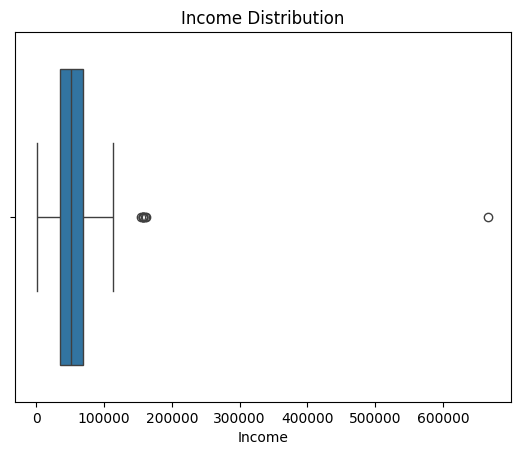

In [17]:
sns.boxplot(x=df["Income"])
plt.title("Income Distribution")
plt.show()

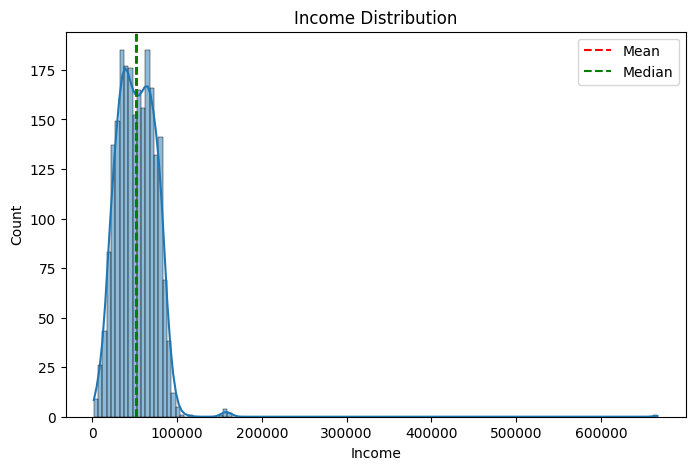

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], kde=True)
plt.axvline(df["Income"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["Income"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.title("Income Distribution")
plt.show()

The Income variable is right-skewed and contains an extreme outlier of approximately 666k. Since the mean is sensitive to extreme values, median imputation will be preferred to ensure robustness.

In [19]:
df['Income'] = df['Income'].fillna(df['Income'].median())

missing_pct = df['Income'].isnull().mean() * 100
print(f"The variable 'Income' contains {missing_pct:.2f}% missing values.")

The variable 'Income' contains 0.00% missing values.


As for the outlier, which is significantly higher than the rest of the observations, likely represents a data entry error. Although tree-based models such as Random Forest are relatively robust to outliers, This observation was removed to prevent potential distortions in the analysis and modelling process.

In [20]:
df = df[df['Income'] != 666666]

#### 4.2 Data Type Conversion
The variable `Dt_Customer` was converted to a datetime format to enable time-based analusis and feature engineering.

In [21]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

print(f"The data type of 'Dt_Customer' is: {df['Dt_Customer'].dtype}")

The data type of 'Dt_Customer' is: datetime64[ns]


#### 4.3 Removing Useless Features
The variables `Z_CostContact` and `Z_Revenue` were identified as constant across all observations, meaning they contain only a single value throughout the dataset. Since variables without variability do not provide useful information for predictive modeling, they were removed from the dataset during the preprocessing stage.

The variable `ID` represents a unique identifier assigned to each customer. Since identifier variables do not contain meaningful information about customer behavior and does not contribute to predicting the response variable, it was removed from the dataset before model training.
By removing this variable, we avoid the risk of the model learning artificial patterns or memorizing the data, called overfitting.

In [22]:
df = df.drop(['Z_CostContact','Z_Revenue', 'ID'], axis=1)
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Income_missing'],
      dtype='object')

### 5. Feature Engeneering

To improve the interpretability and usefulness of the dataset, new variables were derived from existing features.

#### 5.1 Customer Tenure
To capture customer loyalty and engagement, after converting the variable `Dt_Customer` to datetime format, a new variable `Customer_Tenure` was created.
This variable represents the number of days since the customer joined the company.

In [23]:
def create_customer_tenure(df):
    df = df.copy()
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
    df['Customer_Tenure'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days
    return df

df = create_customer_tenure(df)

#### 5.2 Age

The variable `Year_Birth` was transformed into a new feature called `Age`, calculated as the difference between the current year and the customer's birth year. This transformation improves interpretability and allows the model to use age as a meaningful demographic attribute.

In [24]:
current_year = pd.Timestamp.now().year

print(f"The minimum age in the dataset is {(current_year - df['Year_Birth']).min()} and the maximum age is {(current_year - df['Year_Birth']).max()}")

The minimum age in the dataset is 30 and the maximum age is 133


Since the maximum age observed was 133 years, which is not realistic, a thershold of 100 years old was applied when creating the feature in order to filter out unrealistic values.

In [25]:
def create_age(df):
    df = df.copy()
    current_year = pd.Timestamp.now().year
    df['Age'] = current_year - df['Year_Birth']
    df = df[df['Age'] < 100]
    return df

df = create_age(df)

#### 5.3 Aggregated Features  
Aggregated behavioural features were created to summarize customer activity across product categories, purchase channels, and previous campaign responses. These variables include total spending, total number of purchases, and total number of previously accepted campaigns.

In [26]:
def create_aggregated_features(df):
    df = df.copy()

    feature_groups = {
        "Total_Spending": [
            'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
        ],
        "Total_Purchases": [
            'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases'
        ],
        "Total_Accepted_Campaigns": [
            'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5'
        ]
    }

    for new_feature, cols in feature_groups.items():
        df[new_feature] = df[cols].sum(axis=1)

    return df

df = create_aggregated_features(df)

### 6. Exploratory Data Analysis (EDA)
To gain a deeper understanding of the data and to idenify potetial patterns and relationships between variables, an exploratory data analysis was performed. This analysis focuses on the distribution of key features and their relation with the target variable `Response`.

#### 6.1. Distribution of Key Customer Variables

Given the project's goal of predicting customer response to marketing campaing, key variables were selected to describe customer demographics, financial capacity, and the customer's relationship with the company. These variables include Age, Income, Customer_Tenure and Recency.

##### 6.1.1. Age

The age distribution shows that most customers fall within the 35 and 60 years range, indicatig that the company's customer base is primarily composed of adults and middle-aged individuals. A small number of older customers appear as outliers, which may represent long-term clients.

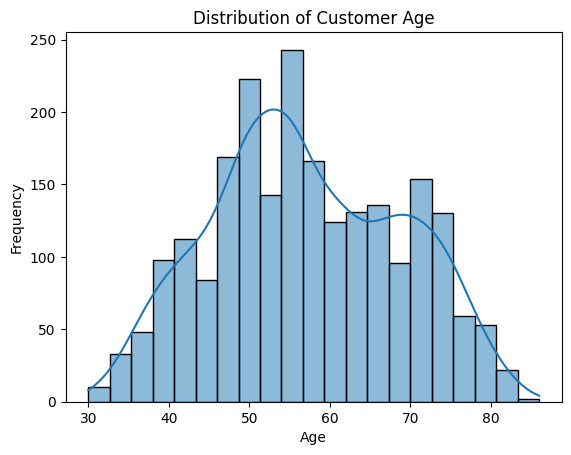

In [27]:
sns.histplot(df['Age'], kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

##### 6.1.2 Income
Income is a very important variable in marketing since it influences directly customers purchasing power.
Income appears to be right-skewed, with most of customers concentrated in lower and middle income ranges and a small number of high-income outliers. These high-income segments may represent valuable targets for premium offerings such as monthly food basket subscription.

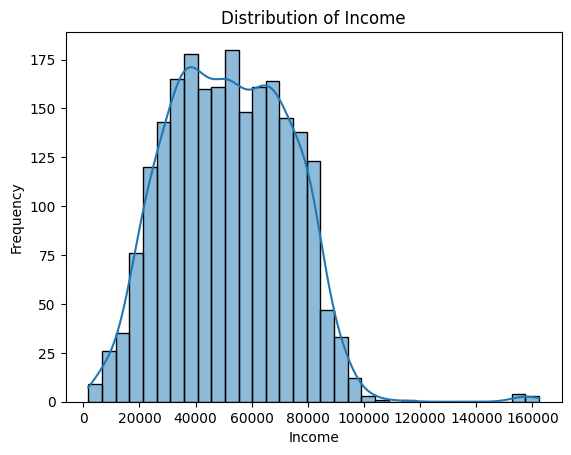

In [28]:
sns.histplot(df['Income'], kde=True)

plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')

plt.show()

##### 6.1.3. Customer Tenure

The `Customer_Tenure` distribution appears to be relatively uniform across all observed data. This sugggests that the dataset includes customers with varying lenghts of relationship with the company, from recent customers to long-term clients. Understand tenure is important, as longer elationships may indicate higher brand loyalty and potentially higher campaign responsiveness.

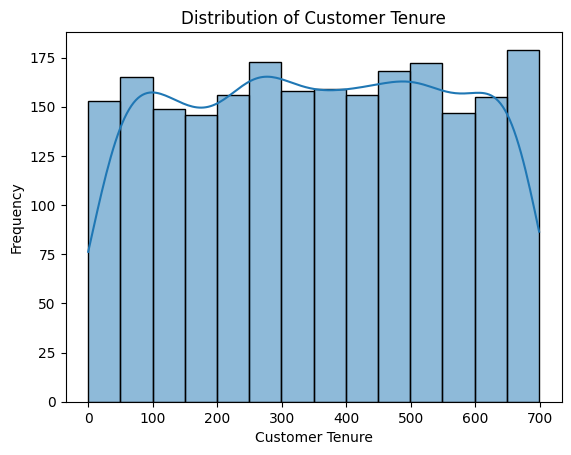

In [29]:
sns.histplot(df['Customer_Tenure'], kde=True)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Customer Tenure')
plt.ylabel('Frequency')

plt.show()

##### 6.1.4. Recency
Recency is a fundamental metric in marketing and RFM models, since it measures how many days has passed since last purchase. Customers with lower recency tend to be more active and more prone to response to campaigns.

Lower values indicate more recent purchases, suggesting higher engagement, while higher values may indicate customers who are less active.

Recency distribution is approximatelly steady within the interval of 0 to 100 days.

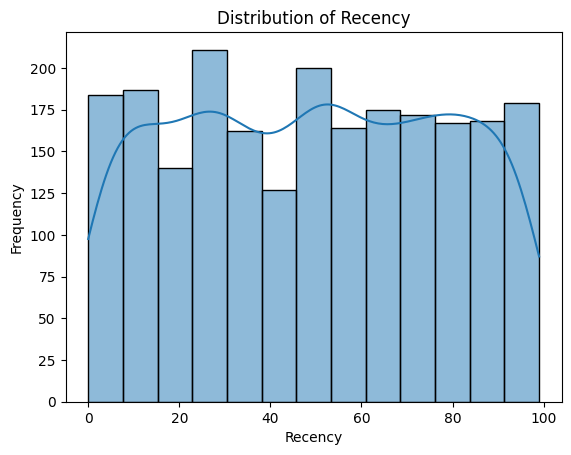

In [30]:
sns.histplot(df['Recency'], kde=True)

plt.title('Distribution of Recency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

#### 6.2. Distribution of Behavioural Variables

The analysis of the distribution of these variables was made with the objective of aalysing the consumption intensity and identifyinf high-value costumers. This variables include Total spending and purchase channels.

##### 6.2.1. Spending Behavior
Regarding `Total_Spending` frequency, it is possible to observe that most of the customers have a spending behaviour relatively low, while a smaller group of customers accounts for higher levels of spending. This suggests the presence of a limited number of high-value customers within the dataset.

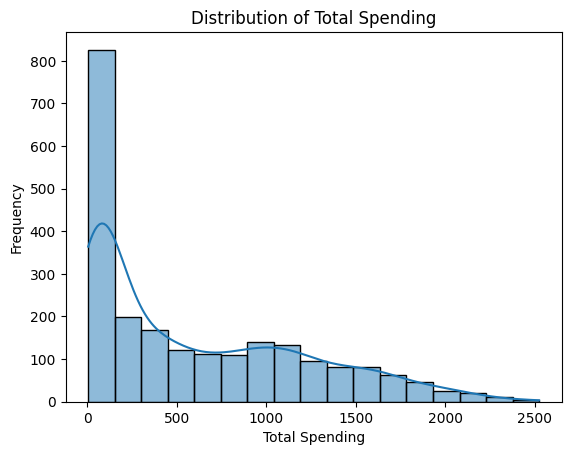

In [31]:
sns.histplot(df['Total_Spending'], kde=True)

plt.title('Distribution of Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Frequency')

plt.show()

##### 6.2.2. Purchase Ativity by Channel
The distribution of total purchases shows a bimodal pattern, suggesting the presence of both low-activity and high-activity customer segments. The boxplot comparison indicates that store purchases have the highest median and variability, making physical stores the most frequently used channel. Web purchases show moderate activity with some high-value outliers, while catalog purchases appear to be the least utilized channel.

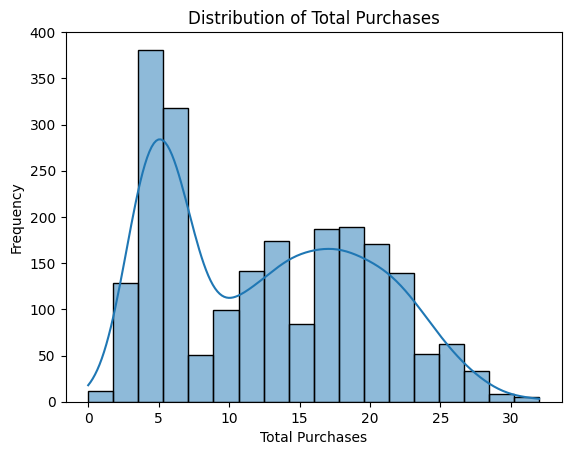

In [32]:
sns.histplot(df['Total_Purchases'], kde=True)

plt.title('Distribution of Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Frequency')

plt.show()

<Axes: >

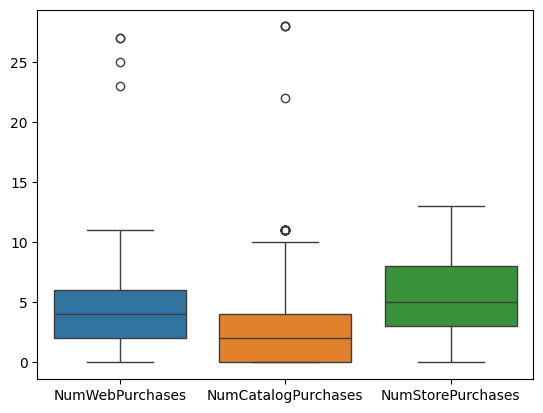

In [33]:
sns.boxplot(data=df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']])

##### 6.2.3. Campaign Acceptance

The vast majority of customers accepted none of the previous campaigns, with very few accepting more than 2. No customer accepted all 5, making Total_Accepted_Campaigns a heavily right-skewed variable where multi-acceptors are rare but likely high-value targets.

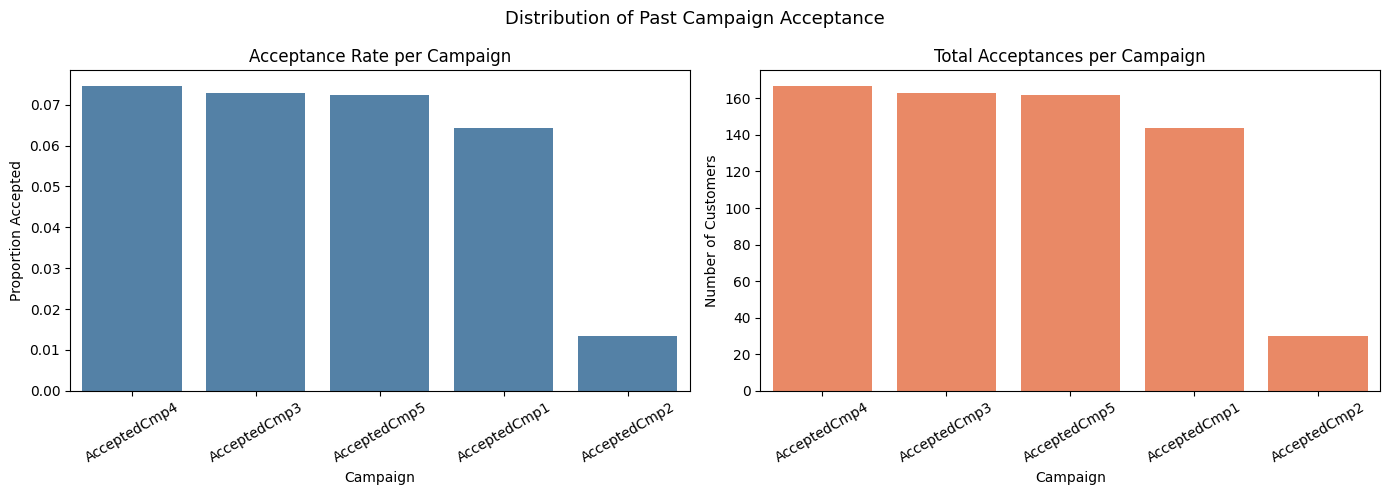

In [34]:
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acceptance_rates = df[cmp_cols].mean().sort_values(ascending=False).reset_index()
acceptance_rates.columns = ['Campaign', 'Rate']
sns.barplot(data=acceptance_rates, x='Campaign', y='Rate', ax=axes[0], color='steelblue')
axes[0].set_title('Acceptance Rate per Campaign')
axes[0].set_ylabel('Proportion Accepted')
axes[0].tick_params(axis='x', rotation=30)

acceptance_counts = df[cmp_cols].sum().sort_values(ascending=False).reset_index()
acceptance_counts.columns = ['Campaign', 'Count']
sns.barplot(data=acceptance_counts, x='Campaign', y='Count', ax=axes[1], color='coral')
axes[1].set_title('Total Acceptances per Campaign')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribution of Past Campaign Acceptance', fontsize=13)
plt.tight_layout()
plt.show()

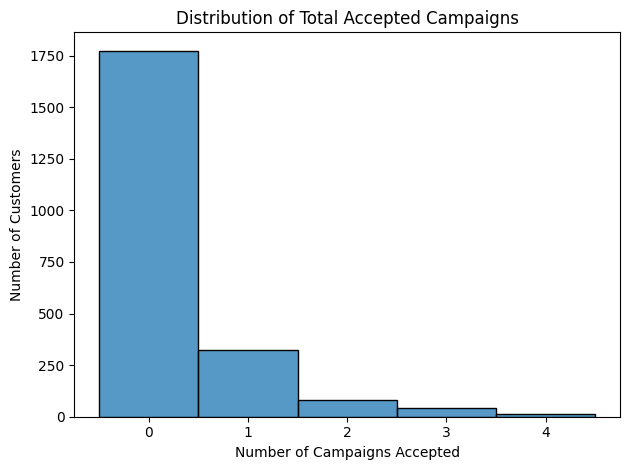

In [35]:
sns.histplot(df['Total_Accepted_Campaigns'], kde=False, discrete=True)

plt.title('Distribution of Total Accepted Campaigns')
plt.xlabel('Number of Campaigns Accepted')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

##### 6.2.4. Web Visits per Month
The distribution is roughly bell-shaped, centered around 5–7 visits per month, with most customers falling within the 3–9 range. There is a small number of extreme outliers reaching 20 visits, which likely represent highly engaged but low-value deal-seekers.

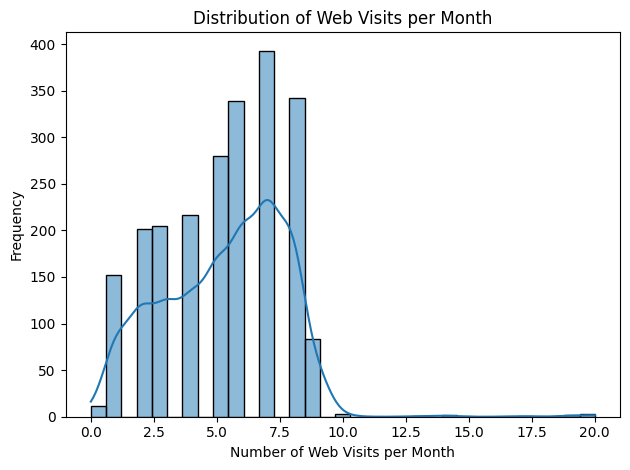

In [36]:
sns.histplot(df['NumWebVisitsMonth'], kde=True)

plt.title('Distribution of Web Visits per Month')
plt.xlabel('Number of Web Visits per Month')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### 6.3. Distribution of Categorical Variables

The analysis of the distribution of these variables was made with the objective of understanding the customers portfolio. This variables includes Education, Marital Status and Household Composition.

**ANALYSYS MISSING**


Distribution of Education

Absolute Frequency:
Education
Graduation    1126
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

Relative Frequency (%):
Education
Graduation    50.36
PhD           21.69
Master        16.55
2n Cycle       8.99
Basic          2.42
Name: proportion, dtype: float64


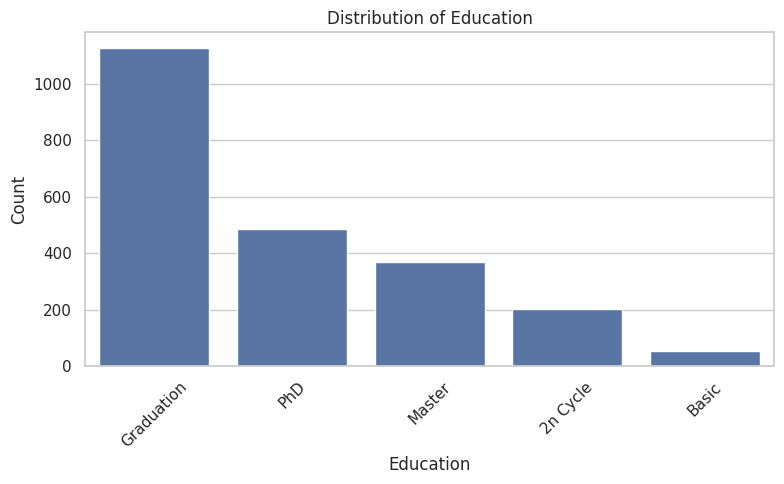


Distribution of Marital_Status

Absolute Frequency:
Marital_Status
Married     864
Together    578
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Relative Frequency (%):
Marital_Status
Married     38.64
Together    25.85
Single      21.42
Divorced    10.33
Widow        3.44
Alone        0.13
Absurd       0.09
YOLO         0.09
Name: proportion, dtype: float64


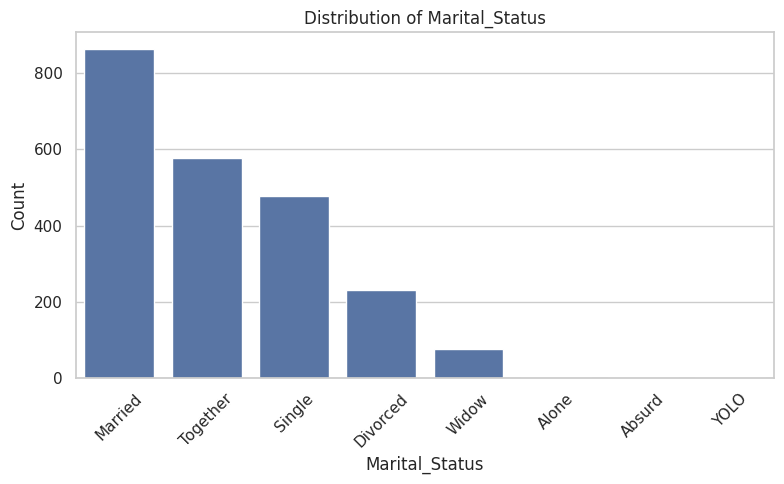

In [37]:
sns.set(style="whitegrid")

categorical_vars = ['Education', 'Marital_Status']

for var in categorical_vars:
    print(f"\n{'='*50}")
    print(f"Distribution of {var}")
    print(f"{'='*50}")

    print("\nAbsolute Frequency:")
    print(df[var].value_counts())

    print("\nRelative Frequency (%):")
    print(round(df[var].value_counts(normalize=True) * 100, 2))

    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=var, order=df[var].value_counts().index)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### 6.3.2. Household Composition


Distribution of Kidhome

Absolute Frequency:
Kidhome
0    1291
1     897
2      48
Name: count, dtype: int64

Relative Frequency (%):
Kidhome
0    57.74
1    40.12
2     2.15
Name: proportion, dtype: float64


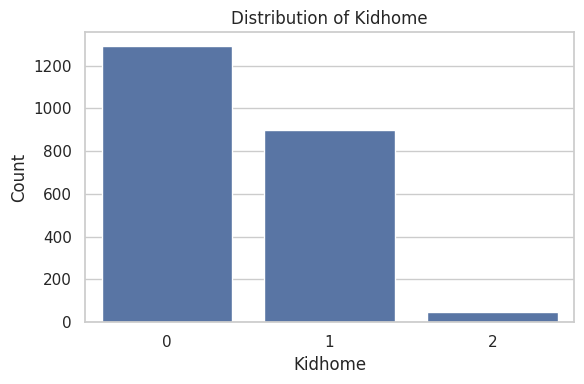


Distribution of Teenhome

Absolute Frequency:
Teenhome
0    1155
1    1029
2      52
Name: count, dtype: int64

Relative Frequency (%):
Teenhome
0    51.65
1    46.02
2     2.33
Name: proportion, dtype: float64


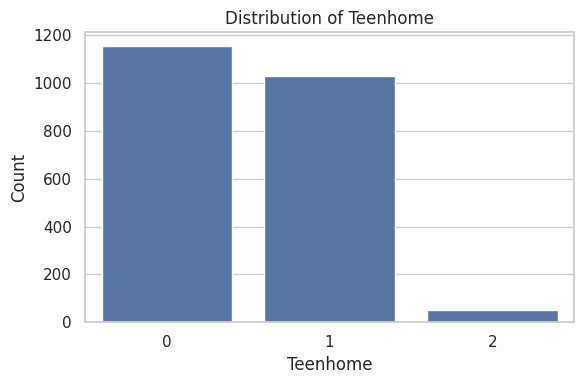

In [38]:
household_vars = ['Kidhome', 'Teenhome']

for var in household_vars:
    print(f"\n{'='*50}")
    print(f"Distribution of {var}")
    print(f"{'='*50}")

    print("\nAbsolute Frequency:")
    print(df[var].value_counts().sort_index())

    print("\nRelative Frequency (%):")
    print(round(df[var].value_counts(normalize=True).sort_index() * 100, 2))

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=var, order=sorted(df[var].unique()))
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

After examining the distribution of key customer variables, the analysis proceeds to behavioural variables that capture purchasing patterns and engagement with the company.

#### 6.4. Bivariate Analysis (Features vs Target)
Following the analysis of the individual distributions of the key varaibles, a bivariate analysis was conducted to explore the relationships between the different features and the target variable `Response`.

The goal is to identify potential patterns and associations that may help explain customer responses to marketing campaigns. By comparing custmer demographics, purchasing behavior and engagement indicators with the target variable, it becomes possible to identify which characteristics are more strongly related to campaing acceptance.

##### 6.4.1. Customer Demographics vs Response


**Age vs Response**  
The distribution of age appears relatively similar between responders and non-responders,
suggesting that age alone is not a strong predictor of campaign response. Both groups share
a similar age profile concentrated between 35 and 60 years, indicating that the campaign
appeal is consistent across age groups.

In [39]:
df.groupby('Response')['Age'].mean()

,Age
Response,
0,57.192955
1,56.583832


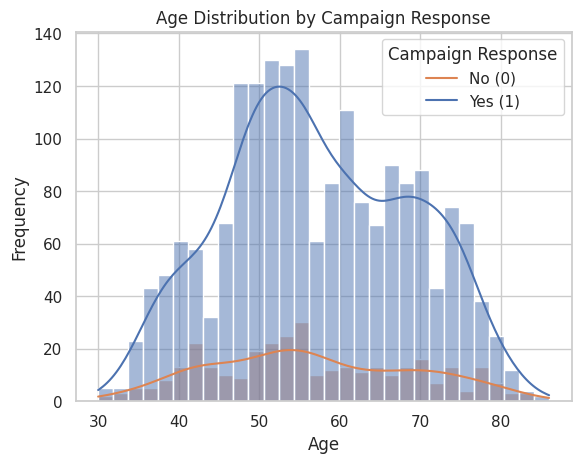

In [40]:
sns.histplot(data=df, x='Age', hue='Response', bins=30, kde=True)

plt.title('Age Distribution by Campaign Response')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.legend(title='Campaign Response', labels=['No (0)', 'Yes (1)'])

plt.show()

The distribution of age appears relatively similar between customers who responded to the campaing an those who did not. This suggests that age alone may not be a strong determinant of campaign response.

**Income vs Response**  
Income levels were analyzed across response groups to determine whether customers with higher purchasing power are more likely to respond to marketing campaigns.


<Axes: xlabel='Response', ylabel='Income'>

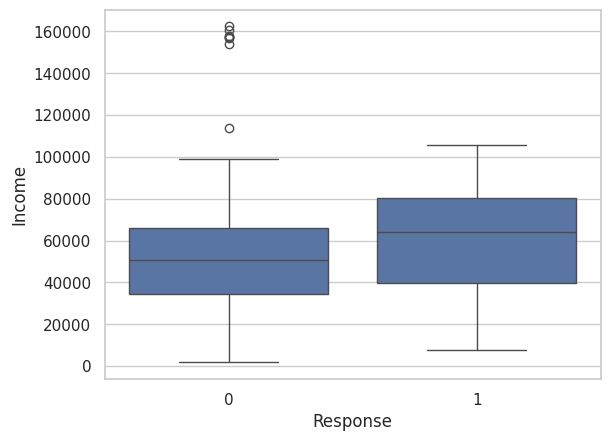

In [41]:
sns.boxplot(x='Response', y='Income', data=df)

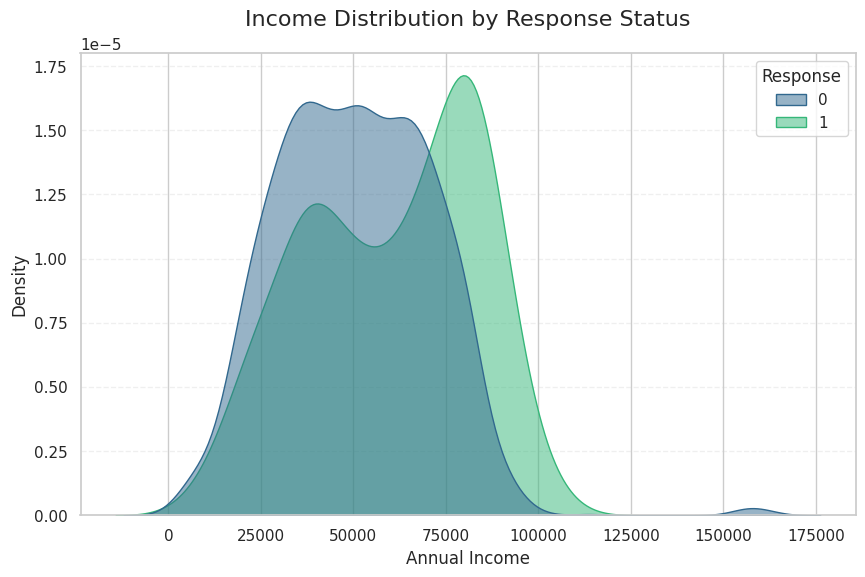

In [42]:

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Income',
    hue='Response',
    fill=True,           # Fills the area under the curve
    common_norm=False,   # Normalizes each curve independently (better for comparing groups of different sizes)
    palette='viridis',   # A nice professional color palette
    alpha=0.5            # Transparency
)


plt.title('Income Distribution by Response Status', fontsize=16, pad=20)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Although the client density is higher between 40k and 50k, the response probability increases drastically in customers with income greater than 70k, reaching the peak success closer to 80k. Income levels above 120k are isolated cases that do not show significant interest in the campaign.

**Customer Tenure vs Response**
  
Customer Tenure represents the number of days since the customer enrolled with the company.
Longer-standing customers may show different levels of brand loyalty and receptiveness to campaigns.


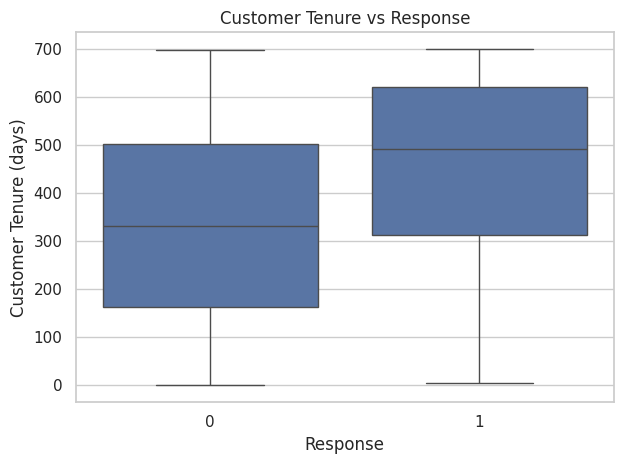

In [43]:
sns.boxplot(x='Response', y='Customer_Tenure', data=df)

plt.title('Customer Tenure vs Response')
plt.xlabel('Response')
plt.ylabel('Customer Tenure (days)')
plt.tight_layout()
plt.show()

Customers who responded tend to have slightly higher tenure, suggesting that longer-standing
customers are marginally more receptive to the offer. However, the difference is modest,
indicating that tenure alone is not a strong discriminating factor.

**Recency vs Response**  
Recency measures the number of days since the customer's last purchase.

Customers with lower recency (more recent purchases)
appear more likely to respond to the campaign,
suggesting that recent engagement is an important behavioral signal.

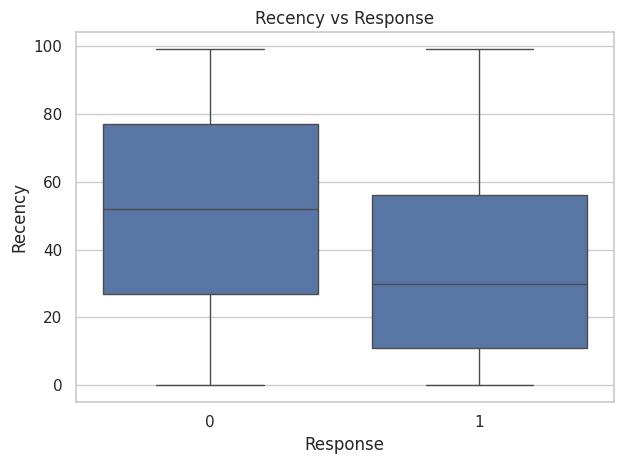

In [44]:
sns.boxplot(x="Response", y="Recency", data=df)

plt.title('Recency vs Response')
plt.xlabel('Response')
plt.ylabel('Recency')
plt.tight_layout()
plt.show()

##### 6.4.2. Customer Behavior vs Response


**Total Spending vs Response**  
One of the most important key variables for our analysis because it represents the customers purchasing behaviour.This relationship was analyzed to determine whether customers with higher purchasing activity are more likely to respond to marketing campaigns.

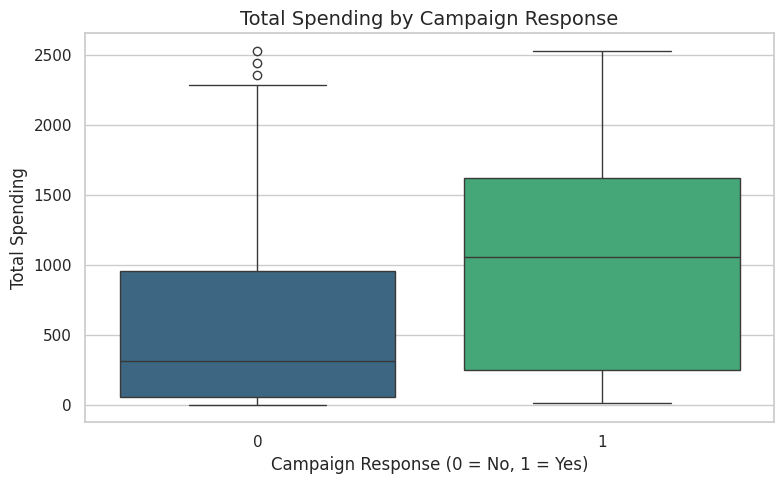

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Response',
    y='Total_Spending',
    data=df,
    hue='Response',
    legend=False,
    palette='viridis'
)

plt.title('Total Spending by Campaign Response', fontsize=14)
plt.xlabel('Campaign Response (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)

plt.tight_layout()
plt.show()

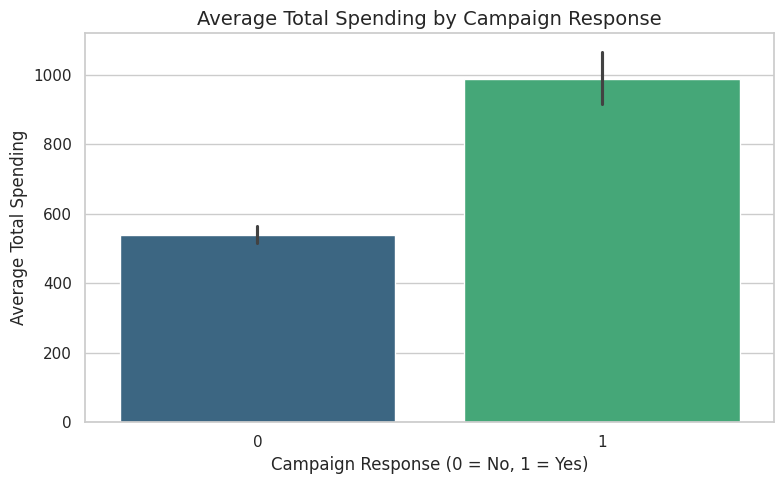

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Response',
    y='Total_Spending',
    data=df,
    hue='Response',
    legend=False,
    palette='viridis'
)

plt.title('Average Total Spending by Campaign Response', fontsize=14)
plt.xlabel('Campaign Response (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Total Spending', fontsize=12)

plt.tight_layout()
plt.show()

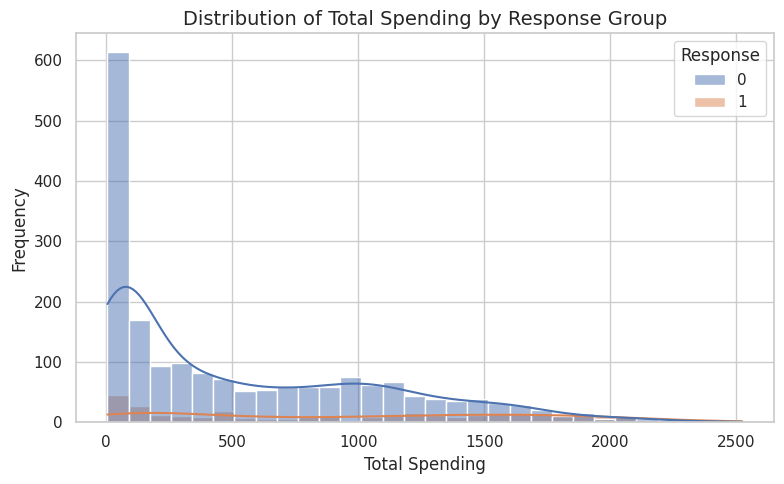

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Total_Spending',
    hue='Response',
    kde=True,
    bins=30
)

plt.title('Distribution of Total Spending by Response Group', fontsize=14)
plt.xlabel('Total Spending', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

Customers who responded to the campaign tend to show slightly higher levels of total spending, suggesting that more active or higher-value customers may be more responsive to marketing initiatives.

**Purchase Activity vs Response**

Responders show notably higher total purchases, with approximately 16 median total purchases, compared to non-responders, with 12 purchases, confirming that more active buyers are more receptive to campaigns.
Deal purchases, kept separate from Total_Purchases as they reflect price sensitivity rather than purchase volume, show virtually no difference between responders and non-responders. This suggests that deal-seeking behavior is not a meaningful signal for campaign response, i.e. customers who respond are not driven by discounts, reinforcing the idea that responders are higher-value, less price-sensitive customers.


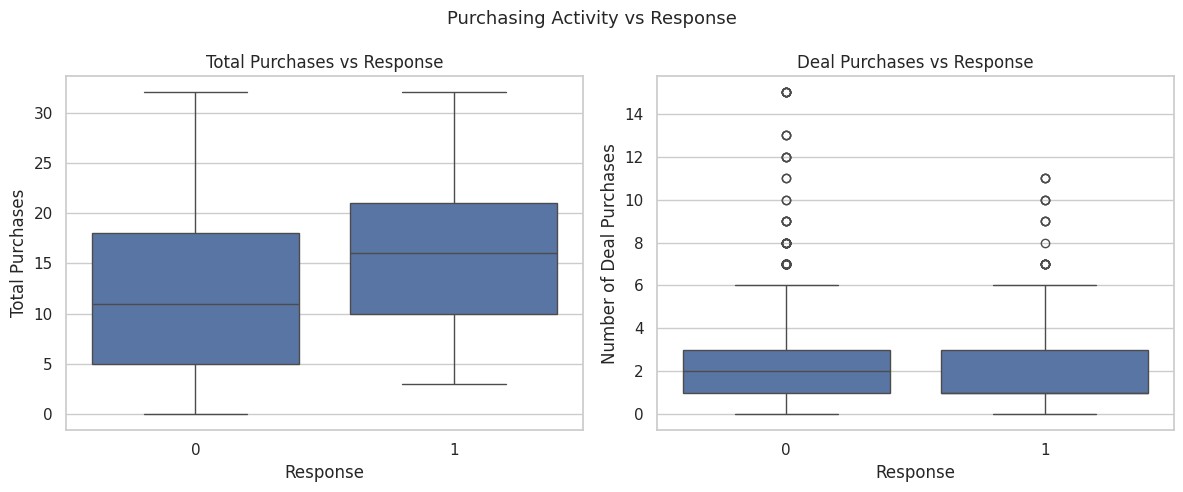

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Response', y='Total_Purchases', data=df, ax=axes[0])
axes[0].set_title('Total Purchases vs Response')
axes[0].set_xlabel('Response')
axes[0].set_ylabel('Total Purchases')

sns.boxplot(x='Response', y='NumDealsPurchases', data=df, ax=axes[1])
axes[1].set_title('Deal Purchases vs Response')
axes[1].set_xlabel('Response')
axes[1].set_ylabel('Number of Deal Purchases')

plt.suptitle('Purchasing Activity vs Response', fontsize=13)
plt.tight_layout()
plt.show()


**Past Campaign Accepts vs Response**  
This is one of the strongest signals in the dataset. Non-responders have a median of 0 accepted campaigns with virtually no spread, while responders show a median of 1 and an IQR ranging from 0 to 2. The contrast is striking: customers who previously engaged with campaigns are substantially more likely to respond again, confirming Total_Accepted_Campaigns as an expected top predictor in the model. Past behavior is the clearest indicator of future receptiveness.

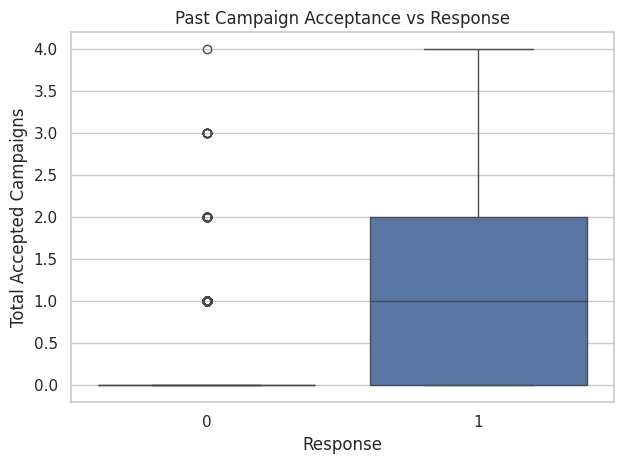

In [49]:
sns.boxplot(x='Response', y='Total_Accepted_Campaigns', data=df)

plt.title('Past Campaign Acceptance vs Response')
plt.xlabel('Response')
plt.ylabel('Total Accepted Campaigns')
plt.tight_layout()
plt.show()

**Number of Web Visitors per Month vs Response**  
Contrary to what might be expected, web visit frequency shows virtually no difference between responders and non-responders — both groups have a median of 6 visits. This confirms that NumWebVisitsMonth is not a direct predictor of campaign response. However, its value lies in its relationship with other features: frequent web visitors tend to be lower-income, lower-spending customers, making it a useful contextual variable rather than a standalone predictor.

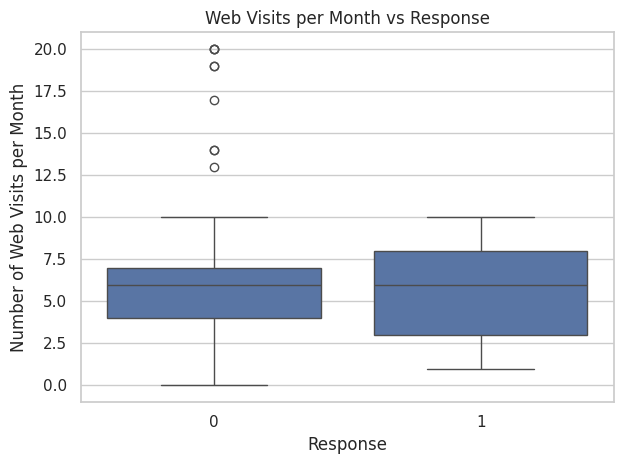

In [50]:
sns.boxplot(x='Response', y='NumWebVisitsMonth', data=df)

plt.title('Web Visits per Month vs Response')
plt.xlabel('Response')
plt.ylabel('Number of Web Visits per Month')
plt.tight_layout()
plt.show()

##### 6.4.3. Categorical Features vs Response

**Education vs Response**  
Response rate decreases clearly with education level. PhD customers show the highest rate, followed by Master and Graduation, in contrast, Basic education shows a very low rate. This suggests a positive relationship between education and campaign receptiveness, likely correlated with higher income and spending capacity.

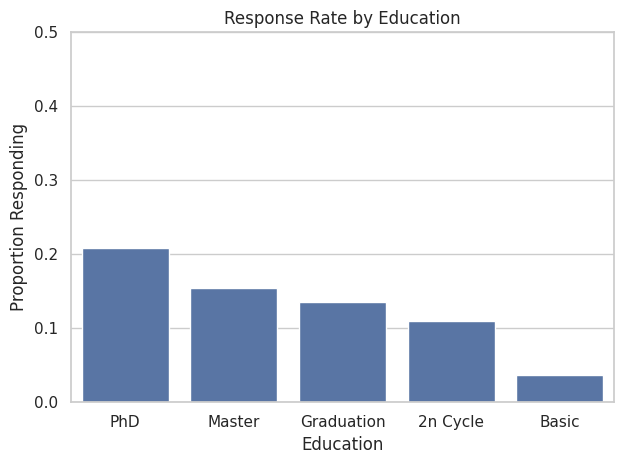

In [51]:
response_rate = df.groupby('Education')['Response'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=response_rate, x='Education', y='Response')
plt.title('Response Rate by Education')
plt.ylabel('Proportion Responding')
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

**Marital Status vs Response**

The categories "Absurd" and "YOLO" show 50% response rates but should be treated with caution, since these are likely data entry errors with very few observations, making their rates statistically unreliable. Among valid categories, "Alone" and "Widow" show the highest rates, while "Married" and "Together" are the lowest, suggesting that customers without a partner may be more receptive to a food basket subscription.


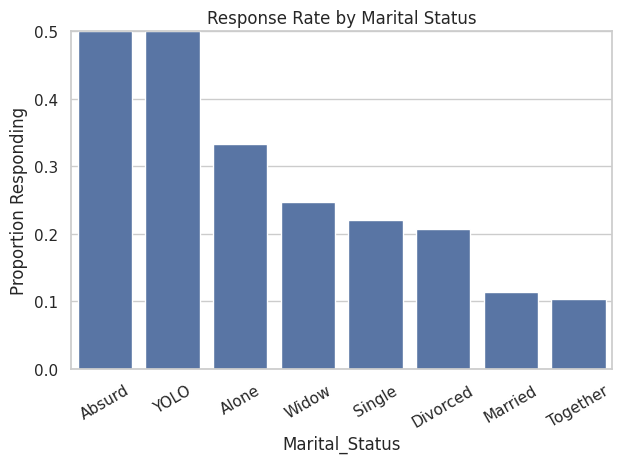

In [52]:
response_rate = df.groupby('Marital_Status')['Response'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=response_rate, x='Marital_Status', y='Response')
plt.title('Response Rate by Marital Status')
plt.ylabel('Proportion Responding')
plt.ylim(0, 0.5)
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Kidhome vs Response**  
A clear negative relationship: customers with no kids at home respond at 17%, dropping to 12% with one kid and only 4% with two, approximately. Having children at home appears to reduce campaign receptiveness, possibly due to different spending priorities.

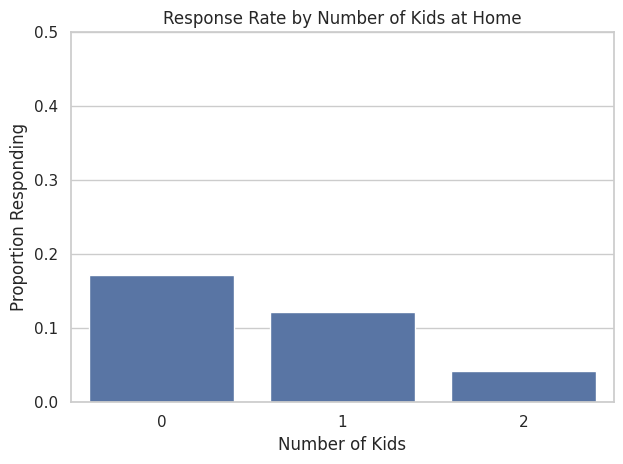

In [53]:
response_rate = df.groupby('Kidhome')['Response'].mean().reset_index()
sns.barplot(data=response_rate, x='Kidhome', y='Response')
plt.title('Response Rate by Number of Kids at Home')
plt.ylabel('Proportion Responding')
plt.xlabel('Number of Kids')
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

**Teenhome vs Response**  
Customers with no teens respond at approximately 20%, dropping significantly to 9% with one teen. The slight recovery at 2 teens is likely due to very few observations in that group and should not be over-interpreted. Overall, the presence of teenagers at home is negatively associated with response, consistent with the pattern observed for kids.

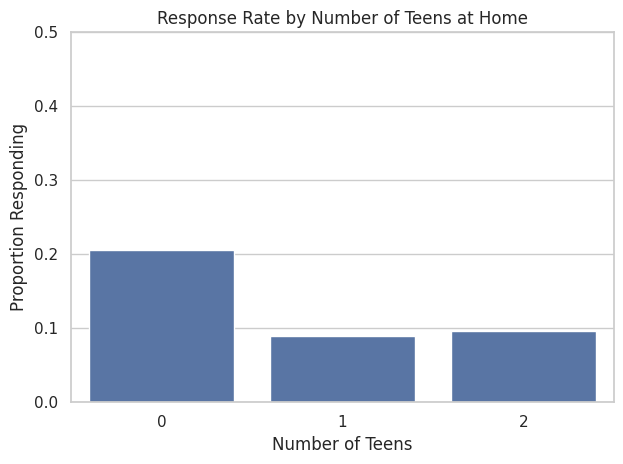

In [54]:
response_rate = df.groupby('Teenhome')['Response'].mean().reset_index()
sns.barplot(data=response_rate, x='Teenhome', y='Response')
plt.title('Response Rate by Number of Teens at Home')
plt.ylabel('Proportion Responding')
plt.xlabel('Number of Teens')
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

### 6.5. Correlation Heatmap

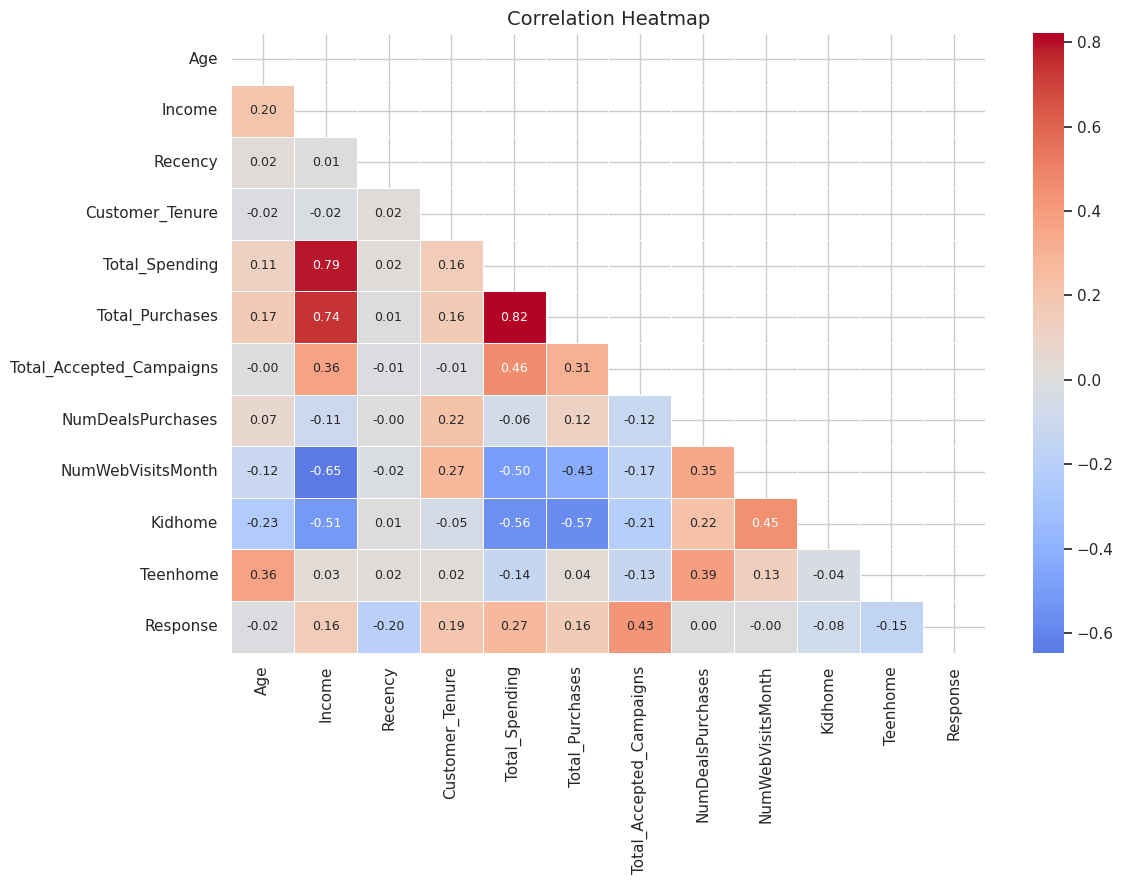

In [55]:
cols_of_interest = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome', 'Response'
]

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(df[cols_of_interest].corr(), dtype=bool))
sns.heatmap(
    df[cols_of_interest].corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

The heatmap confirms the patterns identified throughout the bivariate analysis. Total_Accepted_Campaigns shows the strongest correlation with Response (0.43), followed by Total_Spending (0.27) and Customer_Tenure (0.19). Recency is the only variable with a meaningful negative correlation (-0.20), reinforcing that recent customers are more receptive.
Regarding inter-feature relationships, Total_Spending and Total_Purchases are highly correlated (0.82), and both are strongly driven by Income (0.79 and 0.74 respectively), indicating potential multicollinearity. NumWebVisitsMonth shows strong negative correlations with Income (-0.65), Total_Spending (-0.50) and Total_Purchases (-0.43), confirming that frequent web visitors tend to be lower-value customers. Kidhome negatively correlates with both spending variables (-0.56 and -0.57), consistent with the earlier finding that families with children show lower response rates and spending.


##7. Key Predictive Patterns Identified

The bivariate analysis reveals that behavioral variables consistently outperform demographic ones as predictors of campaign response. Total_Accepted_Campaigns is the strongest signal (r=0.43), confirming that past engagement is the clearest indicator of future receptiveness. Recency shows a clear negative relationship (r=-0.20), meaning recently active customers are more likely to accept the offer. Total_Spending (r=0.27) and Income (r=0.16) also discriminate well between responders and non-responders.
Household composition emerges as a relevant demographic factor — customers with no children or teenagers at home respond at notably higher rates. Education shows a weak positive relationship, while marital status contains unreliable categories (Absurd, YOLO) that should be cleaned or grouped before modeling. NumWebVisitsMonth and NumDealsPurchases show no meaningful relationship with response.
The heatmap also reveals potential multicollinearity worth noting for modeling: Total_Spending and Total_Purchases are highly correlated (0.82), and both are strongly driven by Income (0.79 and 0.74 respectively). Tree-based models handle this robustly, but linear models may require attention.

## 8. Save Clean Dataset

In [56]:
cols_to_drop = ['Dt_Customer', 'Year_Birth']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

if 'Response' in df_clean.columns:
    cols = [c for c in df_clean.columns if c != 'Response'] + ['Response']
    df_clean = df_clean[cols]

output_path = "data/marketing_campaign_clean.csv"
df_clean.to_csv(output_path, index=False)

print(f"Clean dataset saved to: {output_path}")
print(f"Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"\nFinal columns:\n{df_clean.columns.tolist()}")
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")

Clean dataset saved to: data/marketing_campaign_clean.csv
Shape: 2236 rows × 30 columns

Final columns:
['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Income_missing', 'Customer_Tenure', 'Age', 'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns', 'Response']

Missing values: 0
